In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , Sequential

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1334s 8us/step


c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [15]:
X_train = X_train / 255.0
X_test = X_test / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

In [24]:
CNN = Sequential([

    layers.Conv2D(
        32,
        kernel_size=(3,3),
        padding="same",
        activation="relu",
        input_shape=(32,32,3)
    ),
    layers.MaxPooling2D(
        pool_size=(2,2),
        strides=2
    ),

    layers.Conv2D(
        64,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        pool_size=(2,2),
        strides=2
    ),

    layers.Conv2D(
        128,
        kernel_size=(3,3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        pool_size=(2,2),
        strides=2
    ),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

In [25]:
CNN.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [26]:
history = CNN.fit(
    X_train,
    y_train,
    epochs = 10,
    validation_data = (X_test , y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4696 - loss: 1.4476 - val_accuracy: 0.5688 - val_loss: 1.1824
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6484 - loss: 0.9909 - val_accuracy: 0.6777 - val_loss: 0.9199
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7146 - loss: 0.8210 - val_accuracy: 0.7120 - val_loss: 0.8370
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7523 - loss: 0.7059 - val_accuracy: 0.7163 - val_loss: 0.8132
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7821 - loss: 0.6221 - val_accuracy: 0.7429 - val_loss: 0.7763
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8049 - loss: 0.5506 - val_accuracy: 0.7358 - val_loss: 0.7965
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8278 - loss: 0.4910 - val_accuracy: 0.7221 - val_loss: 0.8690
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8472 - loss: 0.

In [22]:
import numpy as np
print(X_train.shape)
print(y_train.shape)

print(X_train.min(), X_train.max())
print(y_train[:20])
print(np.unique(y_train, return_counts=True))

(50000, 32, 32, 3)
(50000,)
0.0 1.0
[6 9 9 4 1 1 2 7 8 3 4 7 7 2 9 9 9 3 2 6]
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]))


In [23]:
print(CNN.optimizer.learning_rate)
print(CNN.loss)

<Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.009999999776482582>
sparse_categorical_crossentropy


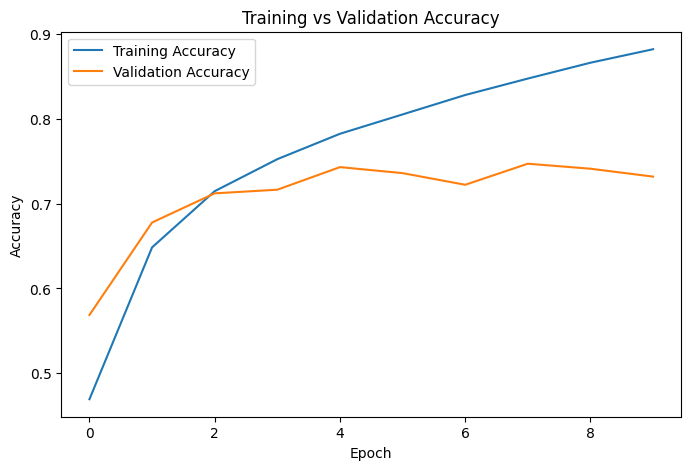

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

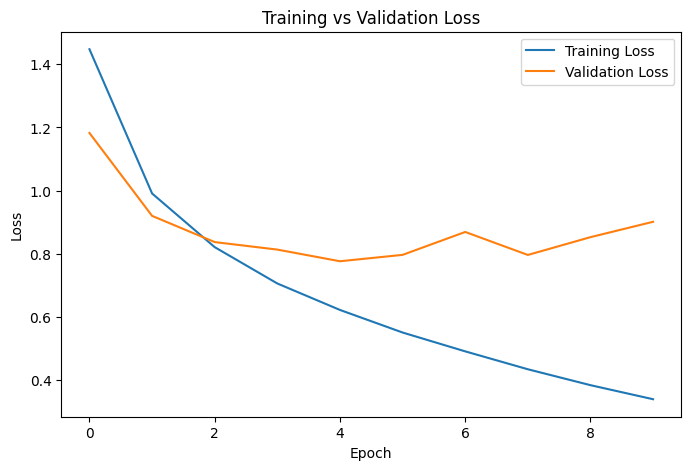

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


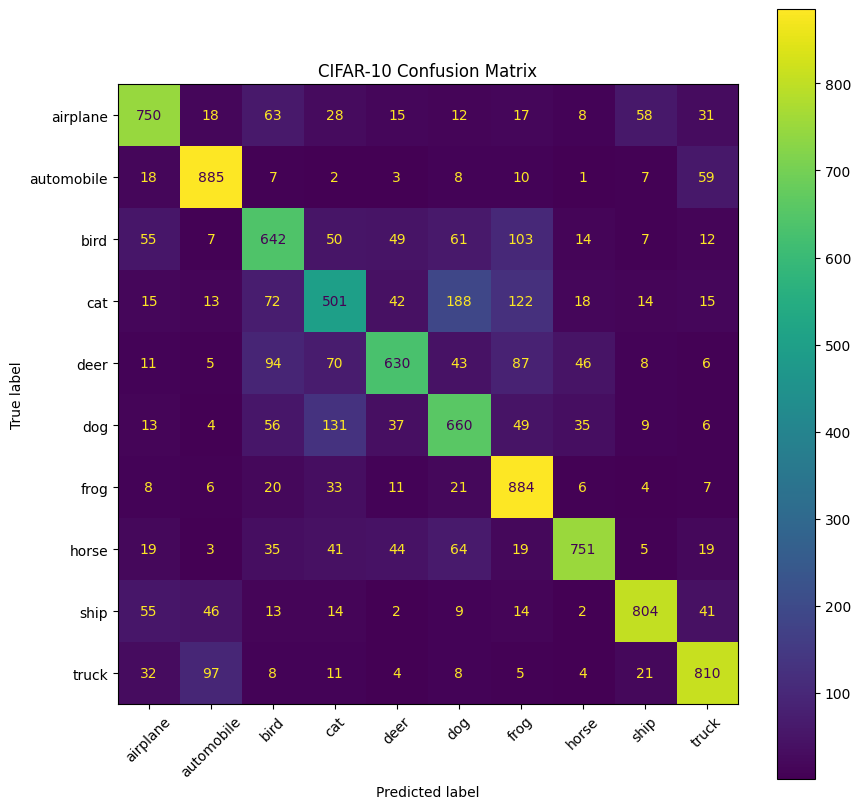

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_pred = CNN.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("CIFAR-10 Confusion Matrix")
plt.show()

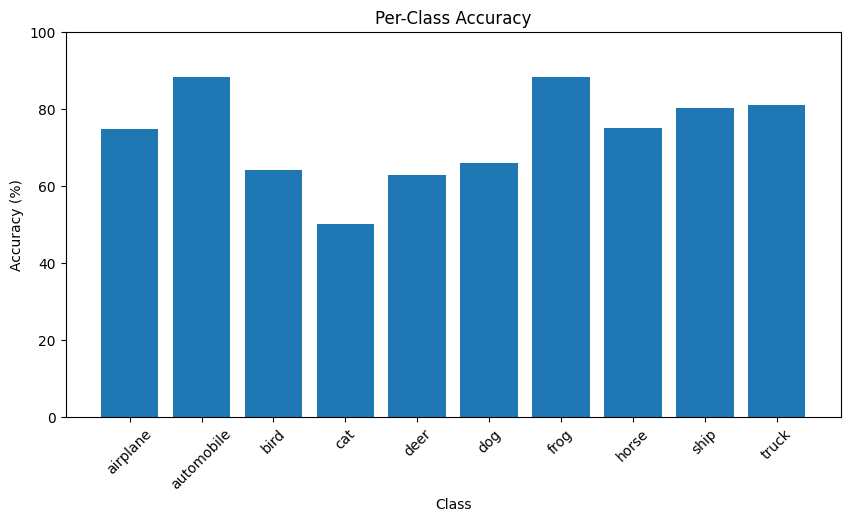

In [31]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10,5))

plt.bar(class_names, class_accuracy * 100)

plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()